# Análise de PLN — Comentários em posts de clubes brasileiros sobre o fim do patrocínio de apostas (bets)

**Autor:** Ítalo Silva (Budah) · **Data da coleta:** 17-18/09/2026

## Objetivo

Em 17/09/2026, diversos clubes de futebol brasileiro publicaram notas oficiais defendendo o mercado regulado de apostas esportivas ("bets") e alertando contra uma possível mudança abrupta na regulamentação, argumentando que isso levaria clubes à insolvência. Este projeto coleta os comentários públicos de torcedores nos posts de **8 clubes/perfis** que publicaram essa nota (ou uma nota equivalente) e aplica técnicas de Processamento de Linguagem Natural (PLN) para entender:

- Quais palavras e temas dominam a reação do público;
- Qual o tom predominante (positivo, negativo ou neutro) em relação à posição dos clubes;
- Se há diferenças de reação entre torcidas de clubes grandes e pequenos, e entre diferentes regiões do país.

## Fonte dos dados

| Clube / perfil | Post |
|---|---|
| Flamengo | https://x.com/Flamengo/status/2100707563805290612 |
| Sport Recife | https://x.com/sportrecife/status/2100745240990584996 |
| Botafogo | https://x.com/Botafogo/status/2100707104235417836 |
| Vila Nova FC | https://x.com/VilaNovaFC/status/2100707900788232358 |
| EC Juventude | https://x.com/ECJuventude/status/2100724092865286397 |
| Atlético Goianiense | https://x.com/ACGOficial/status/2100715360886387149 |
| Grêmio | https://x.com/Gremio/status/2100719819595088157 |
| São Paulo (perfil de torcida "Somos São Paulinos") | https://x.com/somosaopaulinos/status/2100712960562004029 |

**Atenção:** o último post não é da conta oficial do São Paulo FC, e sim de um perfil de torcedores comentando a nota conjunta dos clubes paulistas (FPF, São Paulo, Santos, Palmeiras, Corinthians). Isso é sinalizado na coluna `observacao` do dataset e considerado na leitura dos resultados.

## Metodologia de coleta e suas limitações

O X não oferece acesso de leitura gratuito via API desde 2023 (o modelo atual é pago: pay-as-you-go ou tiers a partir de US$ 200/mês). A alternativa usada aqui foi a **coleta manual assistida**: os posts foram abertos em navegador (sessão autenticada) e os comentários visíveis foram extraídos manualmente por rolagem da página.

Isso implica limitações que devem ficar claras antes de qualquer conclusão:

1. **Amostra não exaustiva e não aleatória.** O X ordena as respostas por relevância/engajamento — a amostra tende a favorecer comentários com mais curtidas, não é uma amostra aleatória de todos os comentários do post.
2. **Amostra desbalanceada entre clubes.** Clubes com posts mais virais (Flamengo, Sport Recife, Grêmio) têm amostras maiores (95 a 108 comentários); clubes menores/menos engajados (Vila Nova, EC Juventude, Atlético Goianiense) têm amostras de 15 a 25 comentários. Comparações percentuais entre clubes pequenos devem ser lidas com cautela pelo tamanho reduzido da amostra.
3. **Coleta manual.** Passível de pequenos erros de transcrição; não captura texto embutido em imagens/vídeos (marcado como "sem texto" quando aplicável).
4. Para um projeto em escala de produção, o caminho recomendado é a API oficial do X (paga), que permite amostragem sistemática e maior volume.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import re
from collections import Counter

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.labelcolor'] = '#52514e'
plt.rcParams['text.color'] = '#0b0b0b'
plt.rcParams['xtick.color'] = '#898781'
plt.rcParams['ytick.color'] = '#898781'

# paleta (validada para daltonismo) usada no projeto.
# Com 8 clubes, evitamos usar 8 cores categóricas distintas num mesmo gráfico
# (a paleta de referência só garante distinção segura até 3 séries em
# comparações all-pairs) -- por isso os gráficos abaixo usam UM único hue
# (azul) para comparações de categoria, e a paleta de status (verde/
# cinza/vermelho, fixa) só para sentimento positivo/neutro/negativo.
COLOR_MAIN = '#2a78d6'   # azul - slot categórico 1 (único hue usado nas comparações entre clubes)
COLOR_POS  = '#0ca30c'   # status: good
COLOR_NEG  = '#d03b3b'   # status: critical
COLOR_NEU  = '#898781'   # muted
SURFACE    = '#fcfcfb'
GRID       = '#e1e0d9'

CMAP_BLUES = LinearSegmentedColormap.from_list(
    'blues_custom', ['#fcfcfb', '#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b']
)

df = pd.read_csv('comentarios_8_clubes.csv')
df['comentario_oficial_do_clube'] = df['comentario_oficial_do_clube'].astype(bool)
df['comentario'] = df['comentario'].fillna('')
print(f"Total de linhas: {len(df)}")
df.head()


Total de linhas: 379


,clube,post_url,autor,handle,comentario,comentario_oficial_do_clube,observacao
0,Flamengo,https://x.com/Flamengo/status/2100707563805290612,Flamengo,@Flamengo,A consequência não será apenas uma porta escan...,True,continuação da nota oficial (não é comentário ...
1,Flamengo,https://x.com/Flamengo/status/2100707563805290612,Matheus,@itstheustheus,Resumo: os clubes querem continuar lucrando co...,False,NaN
2,Flamengo,https://x.com/Flamengo/status/2100707563805290612,bg,@oalexbg_,Vai tomar no cu pô Vai diminuir pra todo mundo...,False,NaN
3,Flamengo,https://x.com/Flamengo/status/2100707563805290612,Jéferfon Menezes,@JefinhoMenes,Antes das bets não existia futebol né,False,NaN
4,Flamengo,https://x.com/Flamengo/status/2100707563805290612,但Esperança,@hopeluta_,Vsf$$$$$$,False,comentário muito curto


## 1. Visão geral dos dados

Removemos as respostas oficiais dos próprios clubes (continuação das notas, não comentários de torcedores) antes de qualquer análise de conteúdo do público.

In [2]:
# separa comentários de torcedores (exclui a resposta oficial do clube)
fans = df[~df['comentario_oficial_do_clube']].copy()
fans['n_palavras'] = fans['comentario'].str.split().apply(len)

resumo = fans.groupby('clube').agg(
    n_comentarios=('comentario', 'count'),
    media_palavras=('n_palavras', 'mean'),
    mediana_palavras=('n_palavras', 'median'),
).round(1).sort_values('n_comentarios', ascending=False)
resumo


,n_comentarios,media_palavras,mediana_palavras
clube,,,
Flamengo,107,29.9,33.0
Sport Recife,95,23.4,20.0
Botafogo,54,21.9,21.5
Gremio,34,24.5,24.0
Sao Paulo (torcida),30,21.1,17.5
Vila Nova FC,24,14.6,10.0
EC Juventude,17,6.1,4.0
Atletico Goianiense,15,15.0,4.0


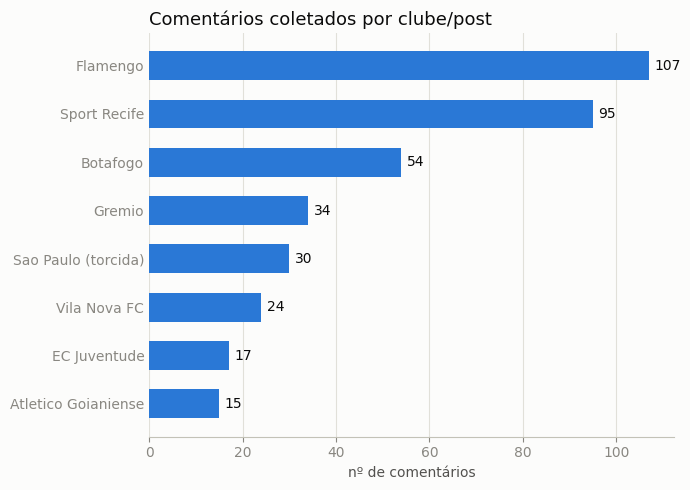

In [3]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ordenado = resumo.sort_values('n_comentarios')
bars = ax.barh(ordenado.index, ordenado['n_comentarios'], color=COLOR_MAIN, height=0.6)
for b in bars:
    w = b.get_width()
    ax.annotate(f'{int(w)}', (w, b.get_y() + b.get_height()/2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=10, color='#0b0b0b')
ax.set_title('Comentários coletados por clube/post', color='#0b0b0b', fontsize=13, loc='left')
ax.set_xlabel('nº de comentários')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig1_volume_comentarios.png', dpi=150, facecolor=SURFACE)
plt.show()


## 2. Pré-processamento de texto

Limpeza padrão de PLN: minúsculas, remoção de menções/URLs/pontuação, tokenização simples e remoção de stopwords do português (lista customizada, incluindo abreviações comuns de redes sociais como "pra", "vc", "q").

In [4]:
STOPWORDS_PT = set("""
de a o que e do da em um para com não uma os no se na por mais as dos como mas
ao ele das seu sua ou quando muito nos já eu também só pelo pela até isso ela
entre depois sem mesmo aos seus quem nas me esse eles você essa num nem suas
meu às minha numa pelos elas qual nós lhe deles essas esses pelas este dele tu
te vocês vos lhes meus minhas teu tua teus tuas nosso nossa nossos nossas dela
delas esta estes estas aquele aquela aqueles aquelas isto aquilo estou está
estamos estão sou somos são era éramos eram foi fomos foram tenho tem temos
tinha tinham há vai vão vem tá ta pra pro vc vcs q né oq aí ai tô to ta
""".split())

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|@\w+|#', '', texto)
    texto = re.sub(r'[^a-zà-ÿ0-9\s]', ' ', texto)
    tokens = [t for t in texto.split() if len(t) > 2 and t not in STOPWORDS_PT]
    return tokens

fans['tokens'] = fans['comentario'].apply(limpar_texto)
fans[['clube', 'comentario', 'tokens']].head(3)


,clube,comentario,tokens
1,Flamengo,Resumo: os clubes querem continuar lucrando co...,"[resumo, clubes, querem, continuar, lucrando, ..."
2,Flamengo,Vai tomar no cu pô Vai diminuir pra todo mundo...,"[tomar, diminuir, todo, mundo, vamos, seguir, ..."
3,Flamengo,Antes das bets não existia futebol né,"[antes, bets, existia, futebol]"


## 3. Palavras mais frequentes (corpus combinado)

Com 8 clubes, um gráfico de barras lado a lado por clube ficaria ilegível. Por isso, a frequência de palavras é analisada primeiro para o **corpus combinado** (todos os torcedores de todos os clubes), que é o recorte que interessa para a análise unificada pedida.

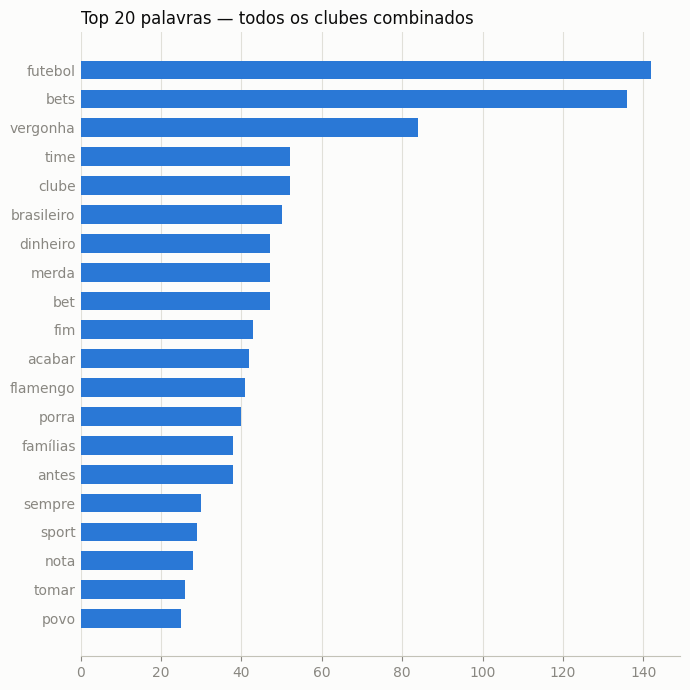

In [5]:
def top_palavras(tokens_series, n=20):
    tokens = [t for lst in tokens_series for t in lst]
    return Counter(tokens).most_common(n)

top_geral = top_palavras(fans['tokens'], n=20)

fig, ax = plt.subplots(figsize=(7, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
palavras, contagens = zip(*top_geral[::-1])
ax.barh(palavras, contagens, color=COLOR_MAIN, height=0.65)
ax.set_title('Top 20 palavras — todos os clubes combinados', loc='left', fontsize=12, color='#0b0b0b')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig2_top_palavras_geral.png', dpi=150, facecolor=SURFACE)
plt.show()


## 4. Análise de sentimento (léxico PT-BR)

**Metodologia:** como não há acesso de rede neste ambiente para baixar um modelo de linguagem pré-treinado (ex.: BERTimbau ou modelos multilíngues do Hugging Face), a análise de sentimento foi feita com abordagem baseada em léxico: um dicionário de palavras positivas e negativas em português (incluindo gírias e xingamentos comuns encontrados no próprio corpus) é usado para pontuar cada comentário.

**Limitações conhecidas dessa abordagem** (importante deixar explícito num projeto de PLN):
- não entende negação ("não é ruim" pontua como negativo);
- não entende sarcasmo/ironia, muito presente nesses comentários;
- xingamento nem sempre significa sentimento negativo *sobre o tema* (às vezes é negativo na forma mas concorda com o clube).

Para um projeto de produção, o próximo passo seria um modelo supervisionado (fine-tuned em português) ou, no mínimo, checagem manual de uma amostra para validar a acurácia do léxico.

In [6]:
PALAVRAS_NEGATIVAS = set("""
vergonha vergonhosa vergonhoso prejudicial prejudica prejudicial prejuizo prejuízo
prejudicando destrutivo destroem destroi destrói destruir vicio vício viciado
viciados endividado endividados endividar miseria miséria adoecendo adoecimento
sofrimento sofrer suicidio suicídio morte matou perder perdendo perderam ganancia
ganância ganancioso corrupto corrupta mentira mentiroso ridiculo ridículo ridicula
nojenta nojentas nojento lixo porcaria merda bosta esgoto praga cancer câncer
sangue inseguranca insegurança desgraca desgraça fodido fodidos fodase foda-se
imbecil incompetente incompetentes incompetente burrice dor dilacerada dilaceradas
tristeza raiva decepcao decepção decepcionante errado chororo chororô trouxa
trouxas vagabundos vagabundo caralho porra puta punheta idiota estupido estúpido
fdp desgracados desgraçados sujo suja fim acabar acabou destruida destruída
bandido bandidos roubam roubo golpe insolvencia insolvência escandalo escândalo
lamentavel lamentável fudido fuder foder tomar merd4 fod4 quiosque patetica
patetico patética patético nojo nojenta nojento canalha parasitas escroto
escrotos abjeta ridicula pobre pobreza miséria arruina arruína arruinada fascistas
extremistas incompetencia
""".split())

PALAVRAS_POSITIVAS = set("""
certo correto corretas correto vanguarda grandeza apoio liberdade responsavel
responsável sustentavel sustentável saude saúde felicidade protecao proteção
seguro segura seguranca segurança garantir garante direitos regulado regulamentado
fiscalizar fiscalizacao fiscalização campeao campeão campea campeã titulo título
titulos títulos gloria glória parabens parabéns otimo ótimo otima ótima justo
justa acerto acertada bom boa excelente merecido merecida coragem
""".split())

def pontuar_sentimento(tokens):
    pos = sum(1 for t in tokens if t in PALAVRAS_POSITIVAS)
    neg = sum(1 for t in tokens if t in PALAVRAS_NEGATIVAS)
    score = pos - neg
    if score > 0:
        return 'positivo', score
    elif score < 0:
        return 'negativo', score
    return 'neutro', score

fans[['sentimento', 'score']] = fans['tokens'].apply(lambda t: pd.Series(pontuar_sentimento(t)))
fans[['clube', 'comentario', 'sentimento', 'score']].head(10)


,clube,comentario,sentimento,score
1,Flamengo,Resumo: os clubes querem continuar lucrando co...,negativo,-2
2,Flamengo,Vai tomar no cu pô Vai diminuir pra todo mundo...,negativo,-4
3,Flamengo,Antes das bets não existia futebol né,neutro,0
4,Flamengo,Vsf$$$$$$,neutro,0
5,Flamengo,O FUTEBOL BRASILEIRO FOI PENTACAMPEÃO DO MUNDO...,positivo,1
6,Flamengo,Apaga essa porra! Falta de responsabilidade so...,negativo,-4
7,Flamengo,o maior time do país se humilhando por dinheir...,negativo,-1
8,Flamengo,Parody account,neutro,0
9,Flamengo,Vc torcedor do Flamengo se votar neste GOVERNO...,negativo,-5
10,Flamengo,"vocês tem que tomar muito no cu, esse time tem...",negativo,-3


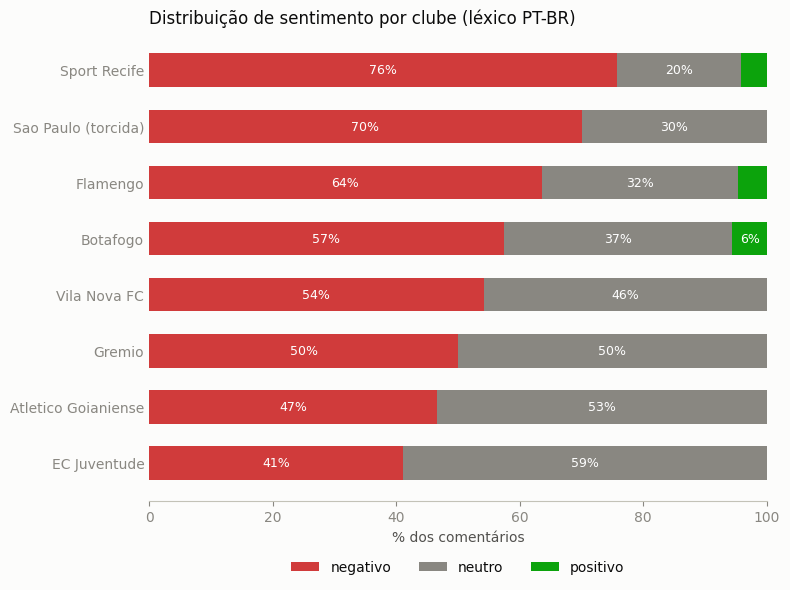

sentimento,negativo,neutro,positivo
clube,,,
Atletico Goianiense,7,8,0
Botafogo,31,20,3
EC Juventude,7,10,0
Flamengo,68,34,5
Gremio,17,17,0
Sao Paulo (torcida),21,9,0
Sport Recife,72,19,4
Vila Nova FC,13,11,0


In [7]:
dist = fans.groupby(['clube', 'sentimento']).size().unstack(fill_value=0)
ordem = ['negativo', 'neutro', 'positivo']
dist = dist.reindex(columns=[c for c in ordem if c in dist.columns])
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100
# ordena pela % de negativo, do maior para o menor
dist_pct = dist_pct.sort_values('negativo')

cores_sent = {'negativo': COLOR_NEG, 'neutro': COLOR_NEU, 'positivo': COLOR_POS}

fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
left = np.zeros(len(dist_pct))
for col in dist_pct.columns:
    vals = dist_pct[col].values
    ax.barh(dist_pct.index, vals, left=left, color=cores_sent[col], label=col, height=0.6)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v/2, i, f'{v:.0f}%', ha='center', va='center', fontsize=9, color='white')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('% dos comentários')
ax.set_title('Distribuição de sentimento por clube (léxico PT-BR)', loc='left', fontsize=12, color='#0b0b0b')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig('fig3_sentimento.png', dpi=150, facecolor=SURFACE)
plt.show()

dist


## 5. Temas recorrentes por clube

Agrupamos palavras-chave em temas manuais (comum em análises exploratórias de PLN quando o corpus é pequeno demais para topic modeling estatístico como LDA renderizar tópicos estáveis) e contamos qual % dos comentários de cada clube toca em cada tema.

Com 8 clubes x 5 temas, um gráfico de barras agrupadas com 8 cores ficaria difícil de ler (e violaria os limites de paleta categórica usados neste projeto). Por isso, usamos um **heatmap** de intensidade única (escala sequencial de azul), que é a forma correta de comparar uma matriz clube × tema sem depender de distinguir 8 hues.

In [8]:
TEMAS = {
    'Apostas/bets': ['bet', 'bets', 'aposta', 'apostas', 'betano', 'regulamentacao', 'regulamentação', 'regulamentar', 'fiscalizar', 'fiscalizacao', 'fiscalização', 'regulado'],
    'Dinheiro/lucro': ['dinheiro', 'lucro', 'lucrando', 'lucrar', 'receita', 'patrocinio', 'patrocínio', 'faturamento', 'milionario', 'milionário', 'bilhoes', 'bilhões', 'salarios', 'salários'],
    'Vicio/familia': ['vicio', 'vício', 'viciado', 'viciados', 'familia', 'família', 'familias', 'famílias', 'endividado', 'endividados', 'suicidio', 'suicídio', 'miseria', 'miséria'],
    'Historia do futebol': ['antes', 'historia', 'história', 'anos', 'campeao', 'campeão', 'titulo', 'título', 'titulos', 'títulos', 'gloria', 'glória'],
    'Linguajar ofensivo': ['porra', 'merda', 'bosta', 'caralho', 'fodido', 'fodidos', 'fdp', 'idiota', 'imbecil', 'vagabundos', 'escroto'],
}

def conta_tema(tokens, palavras_tema):
    texto_set = set(tokens)
    return any(p in texto_set for p in palavras_tema)

linhas = []
for tema, palavras in TEMAS.items():
    for clube in fans['clube'].unique():
        sub = fans[fans['clube'] == clube]
        n = sub['tokens'].apply(lambda t: conta_tema(t, palavras)).sum()
        linhas.append({'tema': tema, 'clube': clube, 'n_comentarios': n,
                        'pct': 100 * n / len(sub) if len(sub) else 0})
temas_df = pd.DataFrame(linhas)
temas_pivot = temas_df.pivot(index='clube', columns='tema', values='pct')
# ordena clubes pelo volume de comentários coletado (do maior para o menor)
temas_pivot = temas_pivot.loc[resumo.index]
temas_pivot.round(1)


tema,Apostas/bets,Dinheiro/lucro,Historia do futebol,Linguajar ofensivo,Vicio/familia
clube,,,,,
Flamengo,60.7,31.8,20.6,23.4,30.8
Sport Recife,41.1,14.7,22.1,32.6,7.4
Botafogo,61.1,20.4,20.4,25.9,13.0
Gremio,44.1,29.4,14.7,20.6,2.9
Sao Paulo (torcida),53.3,26.7,3.3,16.7,6.7
Vila Nova FC,37.5,12.5,20.8,8.3,16.7
EC Juventude,11.8,0.0,5.9,11.8,0.0
Atletico Goianiense,26.7,6.7,0.0,0.0,26.7


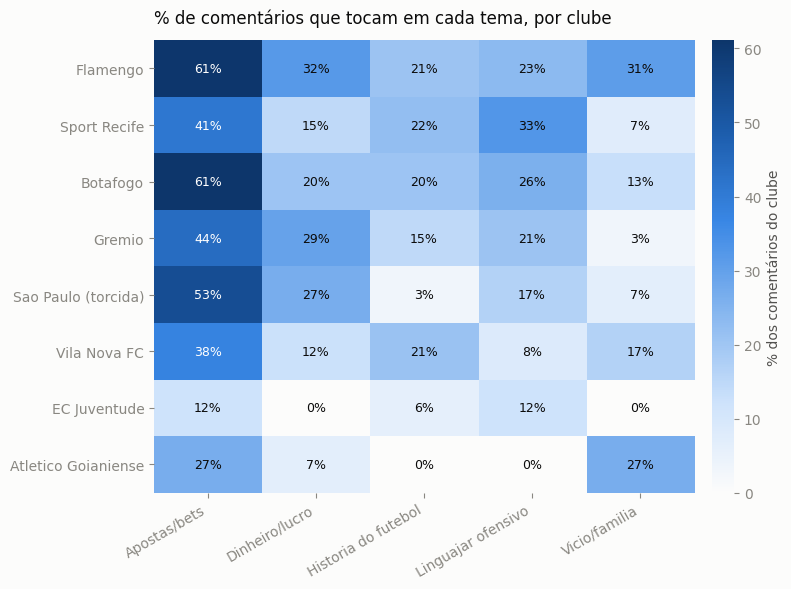

In [9]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
im = ax.imshow(temas_pivot.values, cmap=CMAP_BLUES, aspect='auto', vmin=0, vmax=temas_pivot.values.max())

ax.set_xticks(range(len(temas_pivot.columns)))
ax.set_xticklabels(temas_pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(temas_pivot.index)))
ax.set_yticklabels(temas_pivot.index)

for i in range(temas_pivot.shape[0]):
    for j in range(temas_pivot.shape[1]):
        v = temas_pivot.values[i, j]
        cor_texto = '#ffffff' if v > temas_pivot.values.max() * 0.55 else '#0b0b0b'
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=9, color=cor_texto)

ax.set_title('% de comentários que tocam em cada tema, por clube', loc='left', fontsize=12, color='#0b0b0b', pad=12)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.outline.set_visible(False)
cbar.set_label('% dos comentários do clube', color='#52514e')
plt.tight_layout()
plt.savefig('fig4_temas_heatmap.png', dpi=150, facecolor=SURFACE)
plt.show()


## 6. Reação por clube: negativo vs. positivo em relação à nota

Para facilitar a comparação entre os 8 clubes num único número, calculamos um **saldo de sentimento** (% positivo − % negativo) por clube. Valores bem negativos indicam torcidas majoritariamente contrárias à posição do clube; valores próximos de zero ou positivos indicam reação mais dividida ou favorável.

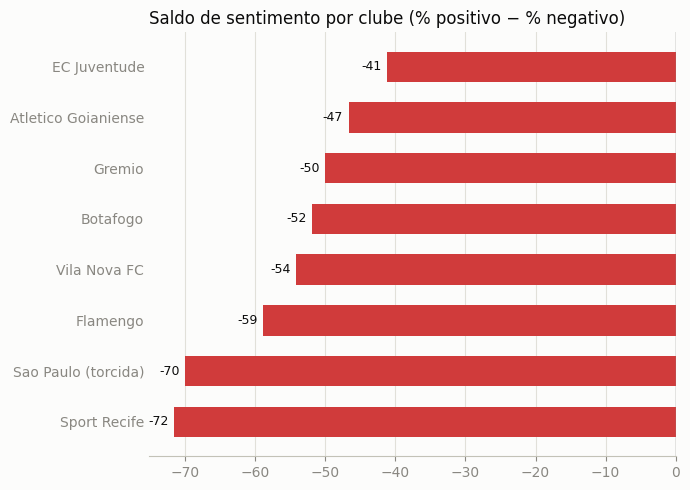

In [10]:
saldo = (dist_pct.get('positivo', 0) - dist_pct.get('negativo', 0)).sort_values()

fig, ax = plt.subplots(figsize=(7, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
cores_saldo = [COLOR_NEG if v < 0 else COLOR_POS for v in saldo.values]
bars = ax.barh(saldo.index, saldo.values, color=cores_saldo, height=0.6)
ax.axvline(0, color='#898781', linewidth=1)
for b in bars:
    w = b.get_width()
    ax.annotate(f'{w:.0f}', (w, b.get_y() + b.get_height()/2),
                xytext=(4 if w >= 0 else -4, 0), textcoords='offset points',
                va='center', ha='left' if w >= 0 else 'right', fontsize=9, color='#0b0b0b')
ax.set_title('Saldo de sentimento por clube (% positivo − % negativo)', loc='left', fontsize=12, color='#0b0b0b')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig5_saldo_sentimento.png', dpi=150, facecolor=SURFACE)
plt.show()


## 7. Conclusões (exploratórias)

Com a ressalva de que a amostra é pequena, desbalanceada entre clubes e não-aleatória (seção de metodologia), alguns padrões aparecem com clareza no material combinado dos 8 clubes:

- **A reação é esmagadoramente negativa em relação ao posicionamento dos clubes em todos os 8 posts** — não há um único clube, entre os analisados, em que o saldo de sentimento seja positivo. A crítica às notas oficiais é o padrão dominante independentemente do tamanho do clube, da região do país ou do momento esportivo.
- **O tema "vício/família" aparece de forma recorrente em praticamente todos os clubes**, muitas vezes à frente do argumento puramente econômico ("dinheiro/lucro") que as próprias notas usaram para se justificar — sinal de que o público reage mais ao argumento social do que ao argumento financeiro dos clubes.
- **Clubes em situação esportiva ruim (Sport Recife, Botafogo, Grêmio, Vila Nova, EC Juventude) atraem uma camada extra de crítica ligada ao desempenho em campo**, que se soma à crítica sobre bets — comentários do tipo "não ganham nada e ainda defendem bet" aparecem em vários desses posts, mas não no do Flamengo, cuja torcida tende a criticar mais o argumento moral da nota do que o desempenho esportivo.
- **Existe uma minoria vocal de apoio** à posição dos clubes, mais visível no post do Flamengo, argumentando que a regulamentação já resolveu boa parte dos problemas do mercado de bets e que a crítica é hipócrita.
- **Repetição de comentaristas entre posts:** vários usuários (ex.: contas que comentaram "Não fará falta nenhuma o futebol brasileiro..." ou "Satoru Indignado") publicaram comentários muito semelhantes ou idênticos em múltiplos posts de clubes diferentes, adaptando apenas o nome do clube — um padrão típico de "comentário-modelo" replicado por usuários engajados no tema, e não uma reação espontânea e independente a cada post especificamente.
- **Linguajar ofensivo é comum em todos os posts** — sinal de que o tema gera bastante emoção/engajamento, mas também uma limitação para a análise de sentimento por léxico, que pode superestimar a negatividade quando o xingamento é dirigido a terceiros (diretoria, governo) e não ao tema das bets em si.
- **O post do perfil de torcida do São Paulo** (que não é a conta oficial do clube) mostra um padrão de reação semelhante ao dos demais, incluindo réplica de comentários vistos em outros posts — indicando que a indignação é dirigida ao conteúdo da nota conjunta dos clubes paulistas, e não ao fato de ser ou não uma conta oficial.

## Próximos passos sugeridos

1. Coletar mais dados via API oficial do X (paga) para uma amostra maior, balanceada entre clubes e sem viés de ordenação por relevância.
2. Validar manualmente uma sub-amostra da classificação de sentimento para medir a acurácia real do léxico usado.
3. Testar um modelo de linguagem pré-treinado em português (ex. BERTimbau) para uma análise de sentimento mais robusta a sarcasmo e negação.
4. Expandir a extração de temas para modelagem de tópicos (LDA/BERTopic) quando o volume de dados permitir, especialmente para os clubes com amostra pequena.
5. Investigar sistematicamente o fenômeno de "comentários replicados" entre posts (mesmo autor/texto adaptado em vários clubes), que pode indicar coordenação ou apenas usuários muito engajados no tema.
